# AA-INDI: actuator and gyro faults through the SDK

Run these cells with the installed `tensoraerospace` package from any working
directory. The example shows agent construction, independent sensor packets,
actuator feedback, continuous learning and plots directly.

At 20 s, a synthetic rigid body loses 30% pitch-actuator effectiveness and gains
a +0.02 rad/s pitch-gyro bias. Compare sensor correction enabled/disabled with
paired seed 17; both controllers continue adapting and receive no event input.
This analytical rotational plant is not a full aerodynamic aircraft model.

## 1. Geometry and nominal surface derivatives

The three-axis nominal angular-acceleration gains are converted into dimensionless
moment derivatives using `AircraftGeometry`. `AAINDIAgent` learns physical moment
coefficients from actual surfaces. Geometry is in SI; angles and rates are radians.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensoraerospace.agent.aa_indi import (
    AAINDIAgent,
    AAINDIConfig,
    AircraftGeometry,
    FlightMeasurement,
    ObserverConfig,
)
from tensoraerospace.agent.aa_indi.kinematics import body_to_ned, rk4
from tensoraerospace.benchmark import ControlBenchmark

plt.rcParams.update(
    {
        "figure.dpi": 125,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
dt, duration, seed = 0.01, 60.0, 17
time = np.arange(round(duration / dt) + 1) * dt
geometry = AircraftGeometry(np.diag([100.0, 150.0, 200.0]), 10.0, 8.0, 1.5)
density, airspeed = 1.2, 40.0
nominal_G = np.diag([4.0, 3.0, 2.0])
derivatives = (geometry.inertia @ nominal_G) / geometry.moment_scale(density, airspeed)[
    :, None
]


## 2. Define this experiment's plant and sensors

The two small functions specify the analytical object and simulated measurements.
Control, observation and identification use library classes. Accelerometers measure
specific force, with gravity removed. Navigation velocity is independent of the
IMU and arrives at 10 Hz; missing samples are `None`. Attitude/IMU arrive at 100 Hz.
The plant has constant navigation velocity and rotating body axes.

In [2]:
def measure_rigid_body(state, actual_surface, t, rng, observer_config):
    """Synthetic sensors for this example's translating rigid body, in SI units."""
    gyro_fault = np.zeros(3)
    if t >= 20.0:
        gyro_fault[1] = 0.02
    imu = np.r_[body_to_ned(state[3:]).T @ np.array([0.0, 0.0, -9.80665]), state[:3]]
    imu += np.r_[np.zeros(3), gyro_fault] + rng.normal(size=6) * observer_config.imu_std
    velocity = (
        np.array([airspeed, 0.0, 0.0]) + rng.normal(scale=0.03, size=3)
        if round(t / dt) % 10 == 0
        else None
    )
    attitude = state[3:] + rng.normal(size=3) * observer_config.navigation_std[3:]
    packet = FlightMeasurement(
        time=t,
        angular_rate=imu[3:],
        specific_force=imu[:3],
        ground_velocity=velocity,
        attitude=attitude,
        surface_position=actual_surface,
        airspeed=airspeed,
        density=density,
    )
    return packet, gyro_fault


def rigid_body_dynamics(state, moment):
    """Euler moment balance and 3-2-1 attitude kinematics of the example plant."""
    omega = state[:3]
    p, q, r = omega
    phi, theta, _ = state[3:]
    euler_rates = np.array(
        [
            p + q * np.sin(phi) * np.tan(theta) + r * np.cos(phi) * np.tan(theta),
            q * np.cos(phi) - r * np.sin(phi),
            (q * np.sin(phi) + r * np.cos(phi)) / np.cos(theta),
        ]
    )
    acceleration = np.linalg.solve(
        geometry.inertia, moment - np.cross(omega, geometry.inertia @ omega)
    )
    return np.r_[acceleration, euler_rates]


## 3. Run the complete predict → integrate → measure → learn loop

The surface limit is 180°/s and the acceleration filter is 10 Hz. Surface doublets
are limited before integration; their actual values are passed to `learn`.
True damaged derivatives and bias are used by the simulator/evaluator only.
Exceptions stop a failed experiment instead of reporting a complete trajectory.

In [3]:
runs = {}
for label, correction_enabled in (("AA-INDI", True), ("Correction disabled", False)):
    # Paired seeds and independent controller/plant state for the two cases.
    rng = np.random.default_rng(seed)
    config = AAINDIConfig(
        geometry=geometry,
        nominal_derivatives=derivatives,
        observer=ObserverConfig(dt=dt),
        enable_sensor_correction=correction_enabled,
        rate_limit=np.deg2rad(180.0),
        acceleration_cutoff_hz=10.0,
        rate_feedback=np.full(3, 4.0),
    )
    agent = AAINDIAgent(config)
    state, applied = np.zeros(6), np.zeros(3)
    sample, gyro_fault = measure_rigid_body(state, applied, 0.0, rng, config.observer)
    states, references, actions, bias_estimates, biases = [state.copy()], [], [], [], []
    for k, t in enumerate(time[:-1]):
        reference = 0.04 * np.sin(2 * np.pi * np.array([0.1, 0.13, 0.17]) * t)
        command = agent.predict(sample, reference, k)
        # Initial surface doublets provide excitation, independently of fault timing.
        if t < 6.0:
            axis, local = int(t // 2), t % 2
            command[axis] += 0.025 if local < 0.4 else (-0.025 if local < 0.8 else 0.0)
        command = np.clip(
            command, applied - config.rate_limit * dt, applied + config.rate_limit * dt
        )
        applied = np.clip(command, -config.magnitude_limit, config.magnitude_limit)
        effective = derivatives.copy()
        if t >= 20.0:
            effective[:, 1] *= 0.7
        moment = geometry.moment_scale(density, airspeed) * (effective @ applied)
        state = rk4(lambda x: rigid_body_dynamics(x, moment), state, dt)
        sample, gyro_fault = measure_rigid_body(
            state, applied, time[k + 1], rng, config.observer
        )
        diagnostics = agent.learn(sample, applied_action=applied)
        if not np.isfinite(state).all():
            raise FloatingPointError(f"Nonfinite rigid-body state at {time[k+1]:g} s")
        states.append(state.copy())
        references.append(reference)
        actions.append(applied.copy())
        bias_estimates.append(agent.observer.faults[3:].copy())
        biases.append(gyro_fault)
    runs[label] = {
        "states": np.asarray(states),
        "references": np.asarray(references),
        "actions": np.asarray(actions),
        "bias_estimates": np.asarray(bias_estimates),
        "biases": np.asarray(biases),
        "estimated_derivatives": agent.identifier.derivatives.copy(),
        "true_derivatives": effective.copy(),
        "updates": [estimator.num_updates for estimator in agent.identifier.estimators],
    }
    assert runs[label]["updates"] == [len(time) - 1] * 3
    print(label, f"completed {time[-1]:g} s; updates per axis:", runs[label]["updates"])


AA-INDI completed 60 s; updates per axis: [6000, 6000, 6000]


Correction disabled completed 60 s; updates per axis: [6000, 6000, 6000]


## 4. Compare tracking and identified coefficients

The metric includes observations from 30 s through 60 s. `np.nextafter`
sets the exclusive start just below 30 s to match `ControlBenchmark`'s
`(start, end]` convention without including the preceding sample.
Low tracking error and accurate physical identification are separate criteria.

In [4]:
metrics = {}
for label, run in runs.items():
    # Compare each resulting state to the reference held over its preceding interval.
    held_reference = np.vstack([run["references"][0], run["references"]])
    metrics[label] = ControlBenchmark().tracking_metrics(
        held_reference,
        run["states"][:, :3],
        dt,
        start=np.nextafter(30.0, -np.inf),
    )
    print(label, "rate RMSE [p, q, r] [rad/s]:", metrics[label]["rmse"])
    print("Estimated derivatives:\n", run["estimated_derivatives"])
    print("True final derivatives:\n", run["true_derivatives"])
print(
    pd.DataFrame(
        {label: m["rmse"] for label, m in metrics.items()},
        index=["Roll p [rad/s]", "Pitch q [rad/s]", "Yaw r [rad/s]"],
    )
)


AA-INDI rate RMSE [p, q, r] [rad/s]: [0.00433254 0.00562043 0.00721986]
Estimated derivatives:
 [[ 3.55703611e-03 -5.35201749e-05  8.93869532e-06]
 [-7.73263491e-04  1.63627963e-02  9.48827803e-05]
 [ 5.23844180e-05  1.51652087e-04  3.52839583e-03]]
True final derivatives:
 [[0.00520833 0.         0.        ]
 [0.         0.021875   0.        ]
 [0.         0.         0.00520833]]
Correction disabled rate RMSE [p, q, r] [rad/s]: [0.00421609 0.02066185 0.0070288 ]
Estimated derivatives:
 [[ 5.20521380e-03  1.70659787e-06 -2.28356831e-08]
 [ 3.54033407e-04  2.34907900e-02 -6.05541721e-04]
 [ 9.06510332e-07  3.12247809e-06  5.20898110e-03]]
True final derivatives:
 [[0.00520833 0.         0.        ]
 [0.         0.021875   0.        ]
 [0.         0.         0.00520833]]
                  AA-INDI  Correction disabled
Roll p [rad/s]   0.004333             0.004216
Pitch q [rad/s]  0.005620             0.020662
Yaw r [rad/s]    0.007220             0.007029


## 5. Plot references, true body rates, bias estimates and actual surfaces

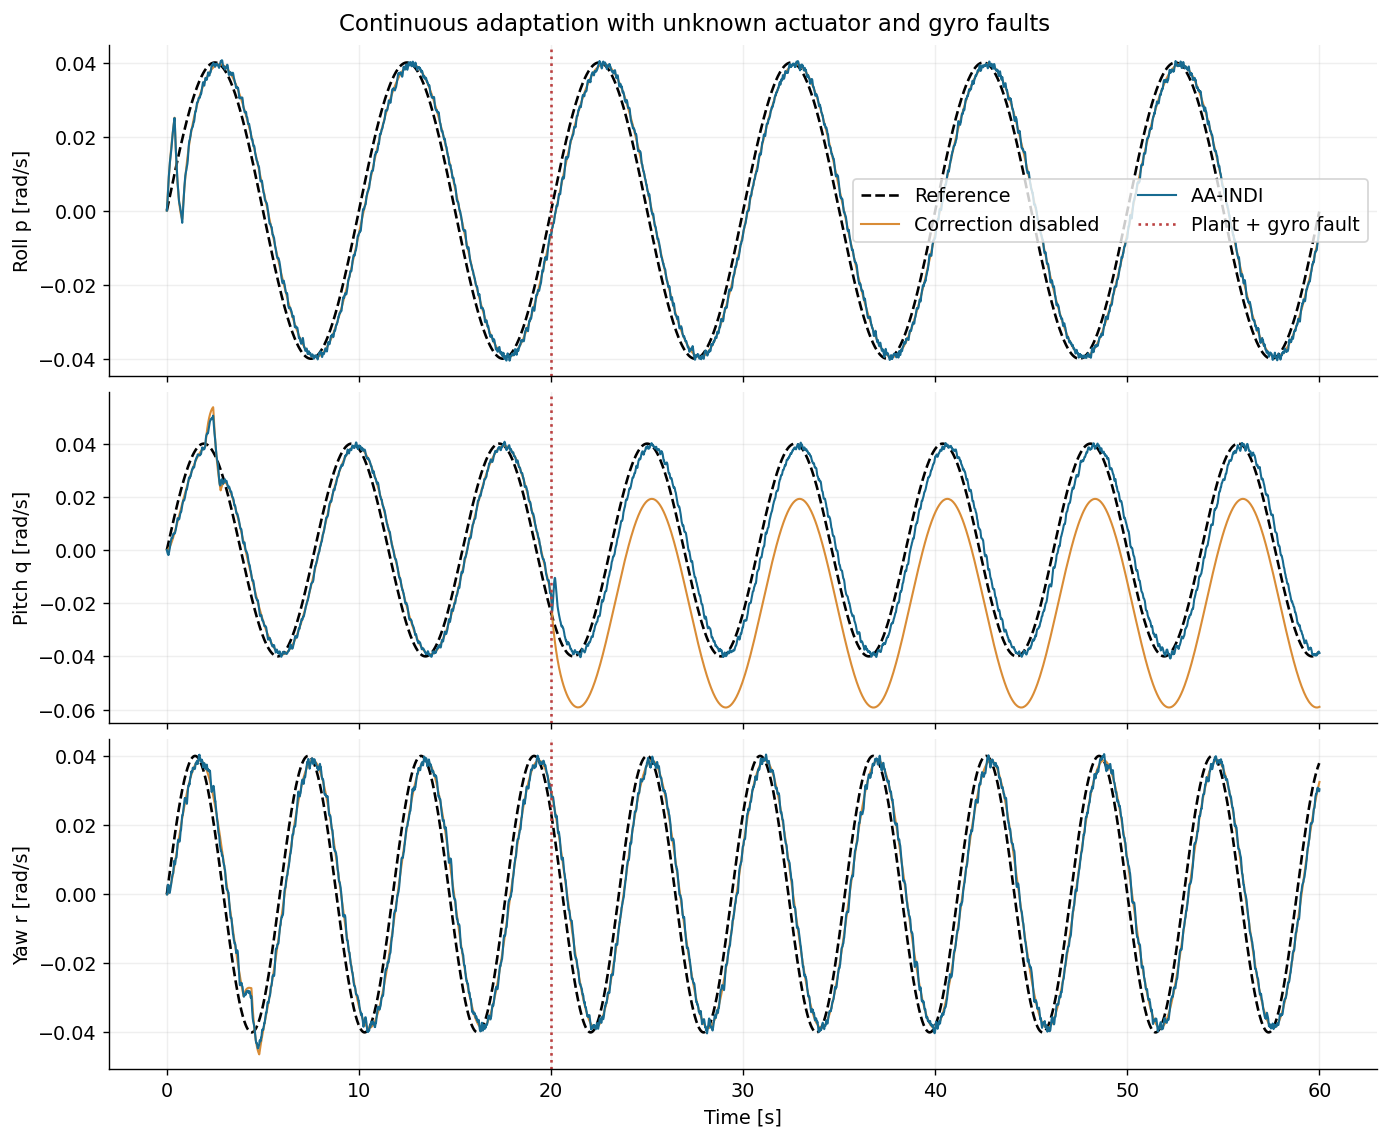

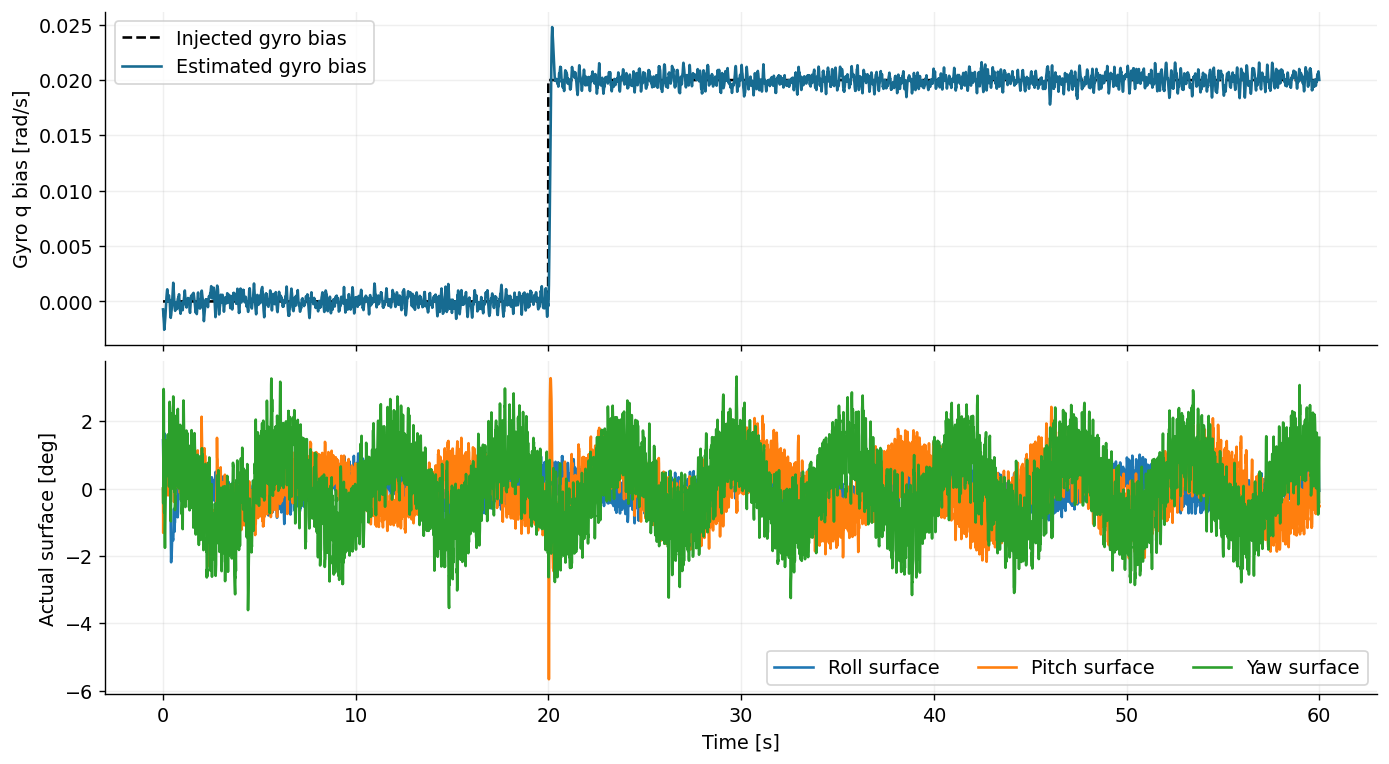

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
for axis, name in enumerate(["Roll p", "Pitch q", "Yaw r"]):
    ax = axes[axis]
    ax.plot(
        time[:-1],
        runs["AA-INDI"]["references"][:, axis],
        "k--",
        lw=1.5,
        label="Reference",
    )
    for label, color in (("Correction disabled", "#d98c36"), ("AA-INDI", "#176b91")):
        ax.plot(time, runs[label]["states"][:, axis], color=color, lw=1.2, label=label)
    ax.axvline(20, color="#bb4040", linestyle=":", label="Plant + gyro fault")
    ax.set_ylabel(name + " [rad/s]")
axes[0].legend(ncol=2)
axes[-1].set_xlabel("Time [s]")
fig.suptitle("Continuous adaptation with unknown actuator and gyro faults")
plt.show()

active = runs["AA-INDI"]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
axes[0].plot(time[1:], active["biases"][:, 1], "k--", label="Injected gyro bias")
axes[0].plot(
    time[1:],
    active["bias_estimates"][:, 1],
    color="#176b91",
    label="Estimated gyro bias",
)
axes[0].set_ylabel("Gyro q bias [rad/s]")
axes[0].legend()
for axis, name in enumerate(["Roll surface", "Pitch surface", "Yaw surface"]):
    axes[1].plot(time[1:], np.rad2deg(active["actions"][:, axis]), label=name)
axes[1].set_ylabel("Actual surface [deg]")
axes[1].set_xlabel("Time [s]")
axes[1].legend(ncol=3)
plt.show()


## Interpretation and next steps

The corrected pitch RMSE is about 0.00562 rad/s versus 0.02066 rad/s without
correction. The estimated pitch derivative still differs from its true damaged
value: this is not proof of complete parameter convergence. The same 10 Hz setup
with a 60°/s slew limit previously diverged, so bandwidth changes require a new run.

Continue with the [native B737 example](example_aaindi_nonlinear_b737.ipynb),
[its elevator fault](example_aaindi_fault_b737.ipynb), or
[the B747 comparison](example_aaindi_vs_pid_lqr_b747.ipynb).